# Análisis de ventas para la tienda Ice.

La tienda online Ice vende videojuegos por todo el mundo. Las reseñas de usuarios y expertos, los géneros, las plataformas (por ejemplo, Xbox o PlayStation) y los datos históricos sobre las ventas de juegos están disponibles en fuentes abiertas.

# Objetivo:

Identificar patrones que determinen si un juego tiene éxito o no, existen datos que se remontan del año 1980 al año 2016 esto para detectar proyectos prometedores y planificar campañas publicitarias para el año 2017.


In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st

In [81]:
df_games = pd.read_csv(r'C:\Users\brahu\Downloads\datasets/games.csv')

In [82]:
df_games.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


In [83]:
df_games.columns = df_games.columns.str.lower()
df_games = df_games.fillna(0)
df_games['year_of_release'] = df_games['year_of_release'].astype(int)
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0,0
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0,0


- En la columna 'year_of_release' se realiza el cambio de valores flotantes a tipo entero para eliminar los decimales y que la lectura del año sea mas exacta.
- En las columnas 'critic_score' y 'user score' los valores ausentes(Nan) se remplazan por ceros('0') para que no haya necesidad de eliminarlos y que los calculos se vean afectados.
- Los valores ausentes se reflejan probablemente por errores de captura o por información incompleta al efectuar una venta, es por eso que lo adecuado en este caso es conservar estos valores ya que en otras columnas si tenemos información.

In [84]:
df_games['total_sales'] = df_games['na_sales'] + df_games['eu_sales'] + df_games['jp_sales'] + df_games['other_sales']
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0,0,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0,0,31.38


- La abreviatura 'tbd' será cambiada a un dato numerico para que no sea tomada en cuenta al momento de realizar los calculos, ya que al no ser un valor que represente una cifra o cantidad, no aporta algo significativo en los calculos.

In [85]:
df_games['year_of_release'].value_counts().sort_index()

year_of_release
0        269
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      62
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
Name: count, dtype: int64

- Existe una diferencia significativa de lanzamientos de juegos en el periodo de los años, esto corresponde a las temporadas donde una plataforma es relevante y al avance tecnológico.

In [86]:
platform_sales = df_games.groupby(['platform','year_of_release'])['total_sales'].sum().reset_index()
platform_sales = platform_sales[platform_sales['year_of_release'] != 0]
#platform_sales = platform_sales.sort_values(ascending=False)
platform_sales.head()

,platform,year_of_release,total_sales
1,2600,1980,11.38
2,2600,1981,35.68
3,2600,1982,28.88
4,2600,1983,5.84
5,2600,1984,0.27


In [87]:
pivot_platform = platform_sales.pivot_table(index='year_of_release',columns='platform',values='total_sales',fill_value=0)
pivot_platform.head()

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SAT,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980,11.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1981,35.68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1982,28.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1983,5.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1984,0.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


<Axes: xlabel='year_of_release'>

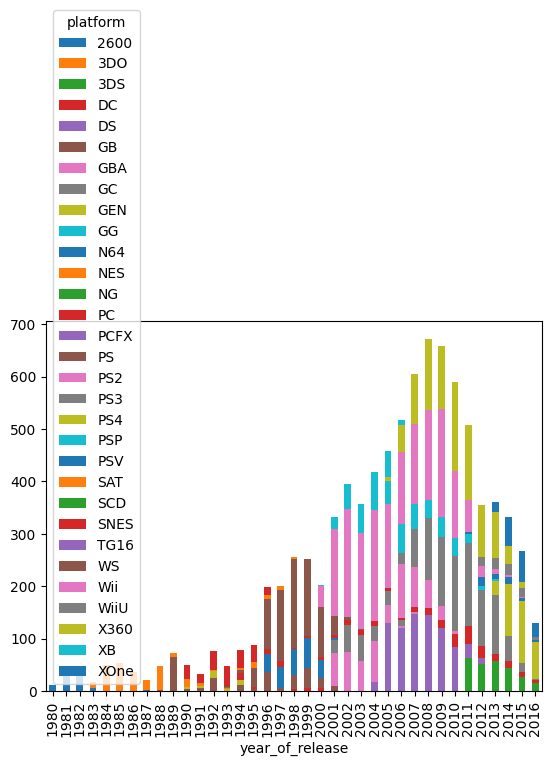

In [88]:
pivot_platform.plot(kind='bar',stacked=True)

- Esta es una gráfica que representa la distribución de las ventas por plataforma y por año, debido a que son muchas plataformas y el rango de años es extenso, es complicado tener una lectura precisa de las ventas de cada plataforma, de igual manera considerar que hay plataformas muy antiguas que ya no existen, por lo tanto lo adecuado es tomar en cuenta solo las plataformas que tienen las mayores ventas y que siguen teniendo relevancia.

In [89]:
platform_sales = df_games.groupby('year_of_release')['total_sales'].sum()
platform_sales = platform_sales.sort_values(ascending=False)
platform_sales.head(6)

year_of_release
2008    671.50
2009    658.82
2007    604.75
2010    590.13
2006    517.71
2011    507.58
Name: total_sales, dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

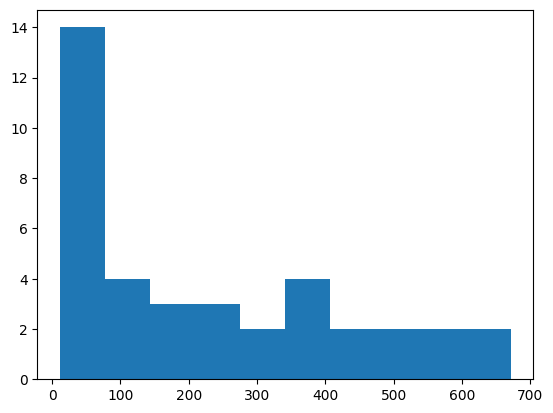

In [90]:
plt.hist(platform_sales)
plt.show

In [91]:
platform_sales = platform_sales.reset_index()
platform_sales = platform_sales[platform_sales['year_of_release'] != 0]

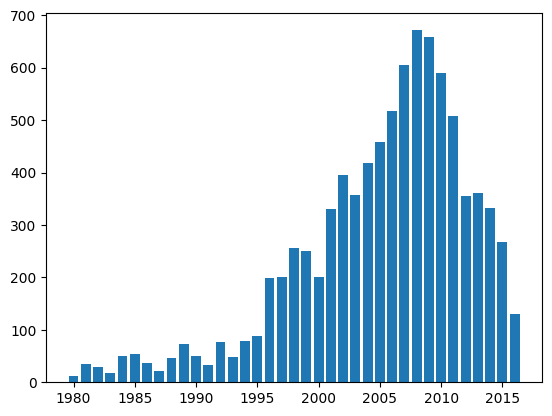

In [92]:
plt.bar(platform_sales['year_of_release'], platform_sales['total_sales'])
plt.show()

- Esta distribución muestra que las ventas comienzan a aumentar significativamente a partir del año 2001.

In [93]:
pivot_platform['global_sales'] = pivot_platform.sum(axis=1)
pivot_platform.head()

platform,2600,3DO,3DS,DC,DS,GB,GBA,GC,GEN,GG,...,SCD,SNES,TG16,WS,Wii,WiiU,X360,XB,XOne,global_sales
year_of_release,,,,,,,,,,,,,,,,,,,,,
1980,11.38,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.38
1981,35.68,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.68
1982,28.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28.88
1983,5.84,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.80
1984,0.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,50.35


In [94]:
top_platform = df_games.groupby(['platform','year_of_release'])['total_sales'].sum().reset_index()
top_platform

,platform,year_of_release,total_sales
0,2600,0,10.50
1,2600,1980,11.38
2,2600,1981,35.68
3,2600,1982,28.88
4,2600,1983,5.84
...,...,...,...
249,XB,2008,0.18
250,XOne,2013,18.96
251,XOne,2014,54.07
252,XOne,2015,60.14


In [95]:
top_5 = top_platform.groupby('platform')['total_sales'].sum().sort_values(ascending=False).head()
top_5

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
Name: total_sales, dtype: float64

- PS2, Xbox 360, PS3, Wii y Nintendo DS son las 5 plataformas mas vendidas

In [96]:
top_5_list = top_5.index.tolist()
top_5_list

['PS2', 'X360', 'PS3', 'Wii', 'DS']

In [97]:
top_5_dist = top_platform[top_platform['platform'].isin(top_5_list)]
top_5_dist

,platform,year_of_release,total_sales
27,DS,0,3.34
28,DS,1985,0.02
29,DS,2004,17.27
30,DS,2005,130.14
31,DS,2006,119.81
...,...,...,...
235,X360,2012,99.74
236,X360,2013,88.58
237,X360,2014,34.74
238,X360,2015,11.96


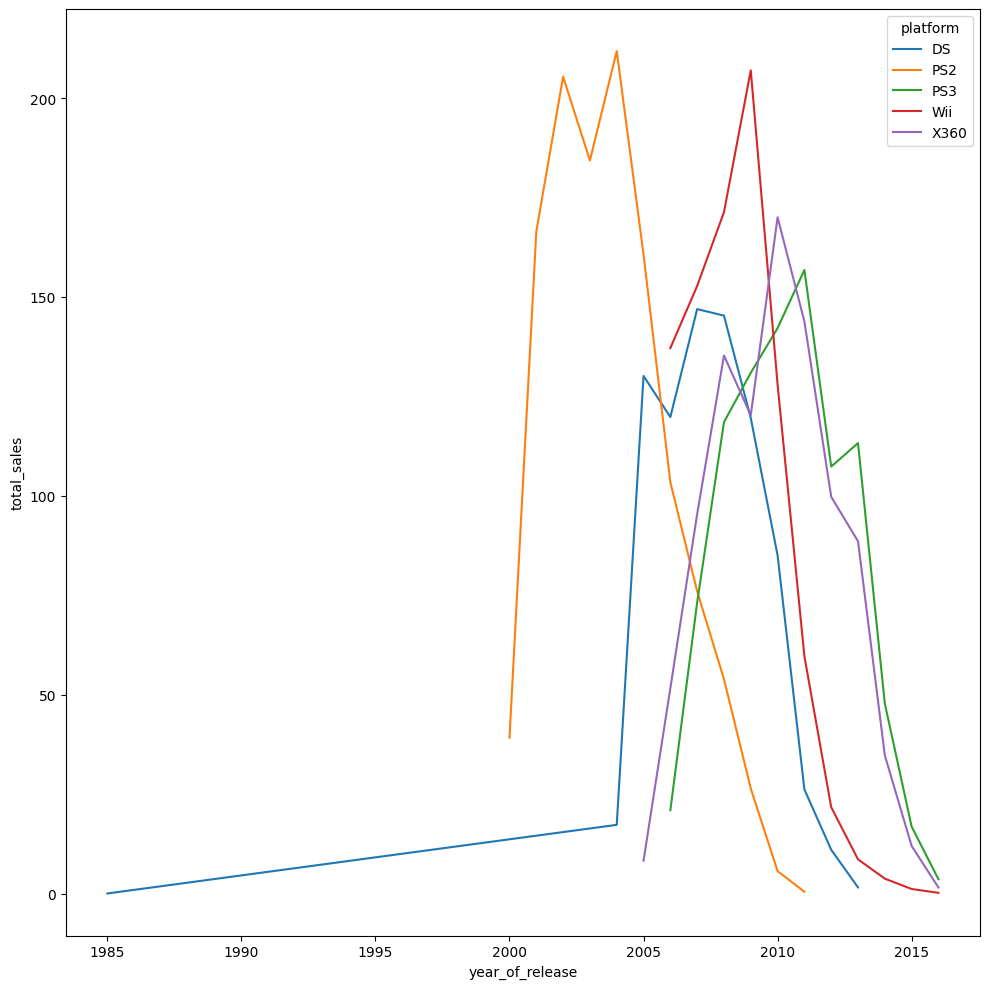

In [98]:
plt.figure(figsize=(10,10))
sns.lineplot(data=top_5_dist[top_5_dist['year_of_release']!=0],x='year_of_release',y='total_sales',hue='platform')
plt.tight_layout()

- Esta gráfica lineal representa el mayor pico ventas de las plataformas mas populares al paso de los años, podemos ver que las plataformas tardan aproximadamente cinco años en aparecer y aproximadamente once años en desaparecer, esto puede variar tomando en cuenta los juegos que son lanzados para cada plataforma y la preferencia de los usuarios. PS2, X360 y PS3 crecen, Wii y DS se reducen.

In [99]:
top_5

platform
PS2     1255.77
X360     971.42
PS3      939.65
Wii      907.51
DS       806.12
Name: total_sales, dtype: float64

<Axes: xlabel='platform', ylabel='total_sales'>

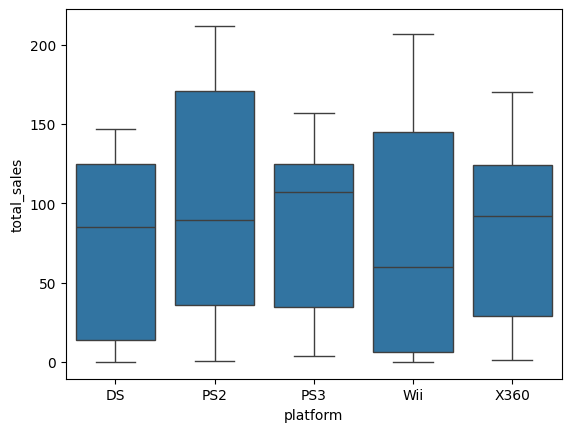

In [100]:
sns.boxplot(data=top_5_dist[top_5_dist['year_of_release']!=0],x='platform',y='total_sales')

- Existe una diferencia minimo de promedio de ventas entre DS, PS2 y X360, mientras que entre PS3 y Wii hay una diferencia significativa.

In [101]:
disp = df_games[df_games['platform'] == 'PS2']
disp['user_score'] = pd.to_numeric(disp['user_score'],errors='coerce')
disp = disp.groupby(['platform','critic_score','user_score'])['total_sales'].sum().sort_values(ascending=False)
disp

C:\Users\brahu\AppData\Local\Temp\ipykernel_24320\4032317207.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  disp['user_score'] = pd.to_numeric(disp['user_score'],errors='coerce')


platform  critic_score  user_score
PS2       0.0           0.0           192.51
          95.0          9.0            20.81
                        8.7            16.15
                        8.4            14.97
          89.0          8.5            13.75
                                       ...  
          54.0          7.4             0.02
          52.0          5.3             0.02
          80.0          8.1             0.01
          64.0          6.8             0.01
          70.0          9.2             0.01
Name: total_sales, Length: 833, dtype: float64

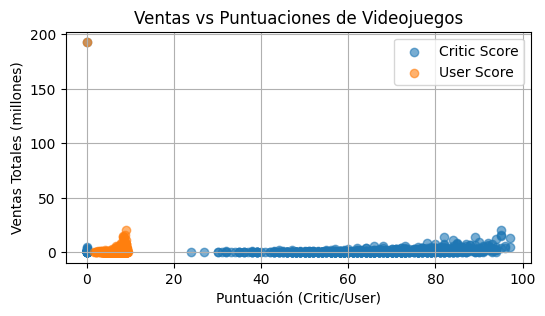

In [102]:
disp = disp.reset_index()
plt.figure(figsize=(6, 3))
plt.scatter(disp["critic_score"], disp["total_sales"], alpha=0.6, label="Critic Score")
plt.scatter(disp["user_score"], disp["total_sales"], alpha=0.6, label="User Score")

plt.title("Ventas vs Puntuaciones de Videojuegos")
plt.xlabel("Puntuación (Critic/User)")
plt.ylabel("Ventas Totales (millones)")
plt.legend()
plt.grid(True)
plt.show()

- Las reseñas de usuarios y profesionales afectan las ventas ya que al dar una puntuación a los juegos se reduce el interes de los usuarios al querer comprar un juego, caso contrario a lo que sucede cuando no existe una reseña.

In [103]:
df_games.head()

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating,total_sales
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,76.0,8,E,82.54
1,Super Mario Bros.,NES,1985,Platform,29.08,3.58,6.81,0.77,0.0,0,0,40.24
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E,35.52
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,80.0,8,E,32.77
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,11.27,8.89,10.22,1.00,0.0,0,0,31.38


In [104]:
dis_gen = df_games.groupby('genre')['total_sales'].sum().sort_values(ascending=False)
dis_gen.head()

genre
Action          1744.17
Sports          1331.27
Shooter         1052.45
Role-Playing     934.56
Platform         827.77
Name: total_sales, dtype: float64

- Estos son los 5 generos mas rentables por mayoría de ventas.

<Axes: title={'center': 'Generos más rentables'}, xlabel='Géneros', ylabel='Ventas totales'>

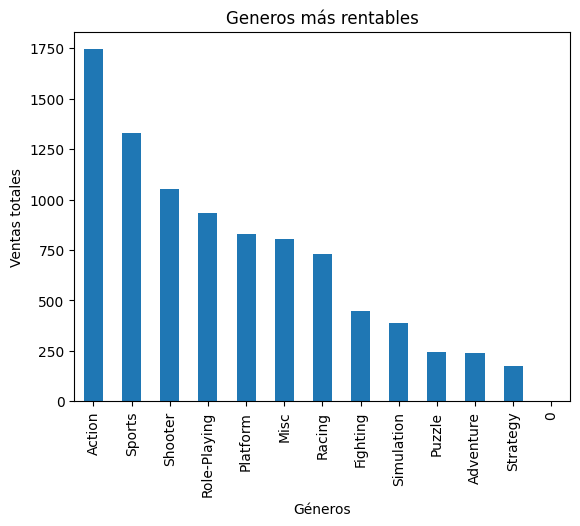

In [105]:

dis_gen.plot(kind='bar',title='Generos más rentables',xlabel='Géneros',ylabel='Ventas totales')

- Los 5 generos mas rentables tienen mayor preferencia de los usuarios por la jugabilidad de los titulos, mientras que los generos restantes no son tan rentables de igual forma por la jugabilidad o por el grado de complejidad que tienen.

In [120]:

top_platforms_na = df_games.groupby("platform")["na_sales"].sum().sort_values(ascending=False).head(5)
top_platforms_eu = df_games.groupby("platform")["eu_sales"].sum().sort_values(ascending=False).head(5)
top_platforms_jp = df_games.groupby("platform")["jp_sales"].sum().sort_values(ascending=False).head(5)

print("Top 5 plataformas en NA:\n", top_platforms_na)
print("\nTop 5 plataformas en EU:\n", top_platforms_eu)
print("\nTop 5 plataformas en JP:\n", top_platforms_jp)

Top 5 plataformas en NA:
 platform
X360    602.47
PS2     583.84
Wii     496.90
PS3     393.49
DS      382.40
Name: na_sales, dtype: float64

Top 5 plataformas en EU:
 platform
PS2     339.29
PS3     330.29
X360    270.76
Wii     262.21
PS      213.61
Name: eu_sales, dtype: float64

Top 5 plataformas en JP:
 platform
DS      175.57
PS      139.82
PS2     139.20
SNES    116.55
3DS     100.67
Name: jp_sales, dtype: float64


<Axes: title={'center': 'Top 5 plataformas en Norteamérica'}, xlabel='Plataformas', ylabel='Ventas totales'>

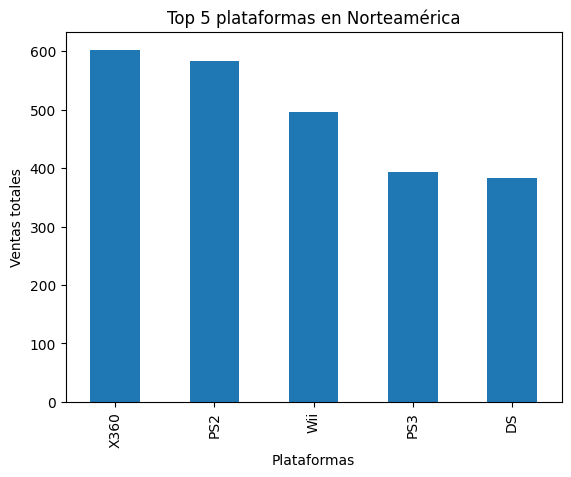

In [118]:
top_platforms_na.plot(kind='bar',title='Top 5 plataformas en Norteamérica',xlabel='Plataformas',ylabel='Ventas totales')

<Axes: title={'center': 'Top 5 plataformas en Estados Unidos'}, xlabel='Plataformas', ylabel='Ventas totales'>

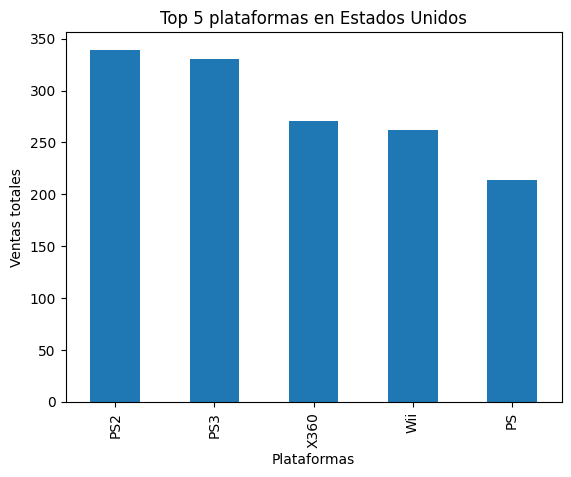

In [117]:
top_platforms_eu.plot(kind='bar',title='Top 5 plataformas en Estados Unidos',xlabel='Plataformas',ylabel='Ventas totales')

<Axes: title={'center': 'Top 5 plataformas en Japón'}, xlabel='Plataformas', ylabel='Ventas totales'>

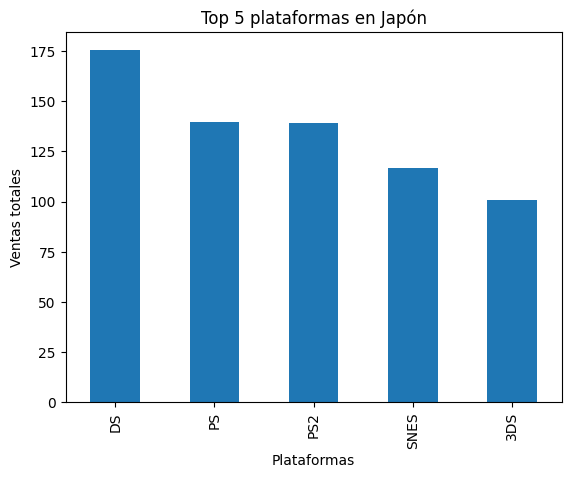

In [115]:
top_platforms_jp.plot(kind='bar',title='Top 5 plataformas en Japón',xlabel='Plataformas',ylabel='Ventas totales')

- En Norteamérica y Estados Unidos suele dominar PS2, X360 y Wii, mientras que en Japón aparecen más DS y 3DS.
- Japón favorece portátiles y consolas nacionales (Nintendo, Sony), mientras que NA/EU muestran más ventas de Xbox y consolas de sobremesa.    

In [107]:
top_genres_na = df_games.groupby("genre")["na_sales"].sum().sort_values(ascending=False).head(5)
top_genres_eu = df_games.groupby("genre")["eu_sales"].sum().sort_values(ascending=False).head(5)
top_genres_jp = df_games.groupby("genre")["jp_sales"].sum().sort_values(ascending=False).head(5)

print("Top 5 géneros en NA:\n", top_genres_na)
print("\nTop 5 géneros en EU:\n", top_genres_eu)
print("\nTop 5 géneros en JP:\n", top_genres_jp)

Top 5 géneros en NA:
 genre
Action      879.01
Sports      684.43
Shooter     592.24
Platform    445.50
Misc        407.27
Name: na_sales, dtype: float64

Top 5 géneros en EU:
 genre
Action     519.13
Sports     376.79
Shooter    317.34
Racing     236.51
Misc       212.74
Name: eu_sales, dtype: float64

Top 5 géneros en JP:
 genre
Role-Playing    355.41
Action          161.43
Sports          135.54
Platform        130.83
Misc            108.11
Name: jp_sales, dtype: float64


<Axes: title={'center': 'Top 5 géneros en Norteamérica'}, xlabel='Géneros', ylabel='Ventas totales'>

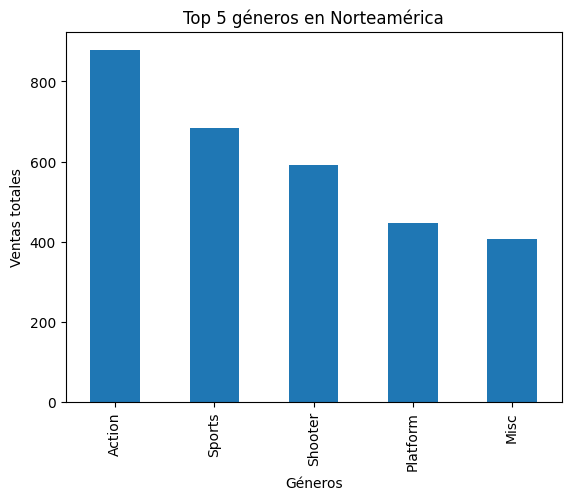

In [121]:
top_genres_na.plot(kind='bar',title='Top 5 géneros en Norteamérica',xlabel='Géneros',ylabel='Ventas totales')

<Axes: title={'center': 'Top 5 géneros en Estados Unidos'}, xlabel='Géneros', ylabel='Ventas totales'>

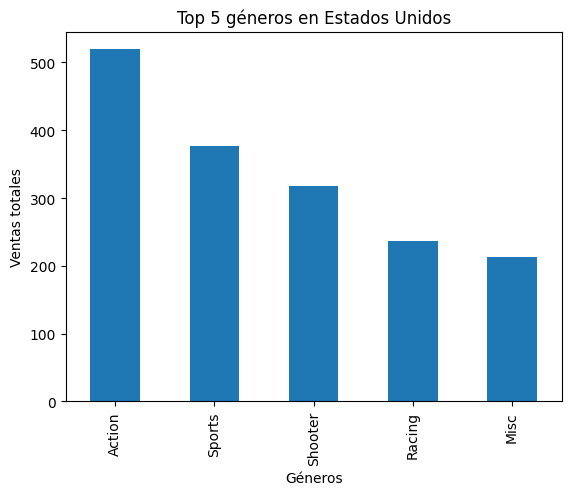

In [122]:
top_genres_eu.plot(kind='bar',title='Top 5 géneros en Estados Unidos',xlabel='Géneros',ylabel='Ventas totales')

<Axes: title={'center': 'Top 5 géneros en Japón'}, xlabel='Géneros', ylabel='Ventas totales'>

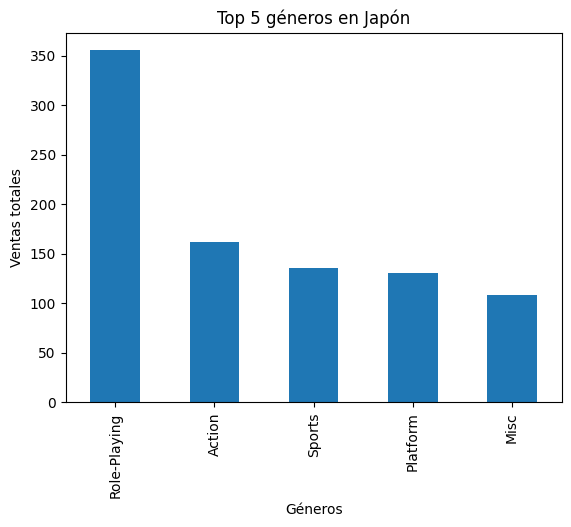

In [123]:
top_genres_jp.plot(kind='bar',title='Top 5 géneros en Japón',xlabel='Géneros',ylabel='Ventas totales')

- NA/EU tienen más preferencia por los géneros de Shooter, Action, Sports, Racing.
- JP prefiere Role-Playing (RPG), Action y Fighting, con menos jugabilidad de Shooter.

In [108]:
rating_sales = df_games.groupby("rating")[["na_sales","eu_sales","jp_sales"]].sum()
print(rating_sales)

        na_sales  eu_sales  jp_sales
rating                              
0        1242.46    613.83    841.96
AO          1.26      0.61      0.00
E        1292.99    710.25    198.11
E10+      353.32    188.52     40.20
EC          1.53      0.11      0.00
K-A         2.56      0.27      1.46
M         748.48    483.97     64.24
RP          0.00      0.08      0.00
T         759.75    427.03    151.40


<Axes: title={'center': 'Ventas por Rating'}, xlabel='Rating', ylabel='Ventas totales'>

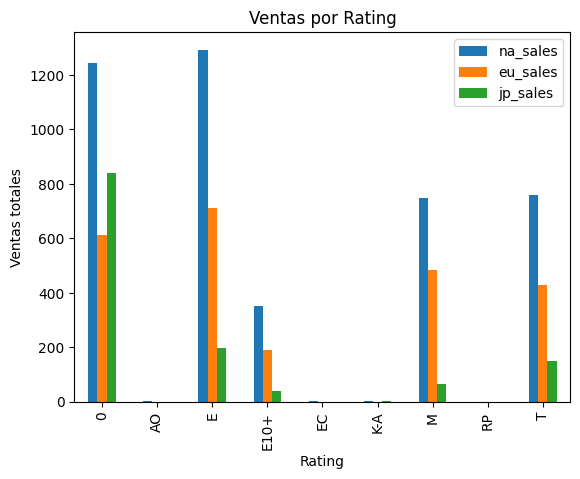

In [126]:
rating_sales.plot(kind='bar', title= 'Ventas por Rating', xlabel='Rating', ylabel='Ventas totales')

- En Norteamérica los juegos con rating 0 y E son los que mas se venden. 
- En NA/EU, los juegos con rating M y T tienden a venderse muy bien.
- En JP, los ratings son menos influyentes, y predominan los juegos E/T (Nintendo, RPGs).

# Pruebas de hipótesis.

In [109]:

xbox_one = df_games.loc[df_games["platform"] == "XOne", "user_score"]
pc = df_games.loc[df_games["platform"] == "PC", "user_score"]

xbox_one = pd.to_numeric(xbox_one, errors="coerce").dropna()
pc = pd.to_numeric(pc, errors="coerce").dropna()
alpha = 0.05
results = st.ttest_ind(xbox_one, pc,equal_var=False)

print('valor p: ', results.pvalue)

if (results.pvalue < alpha):
    
    print("Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.")
else:    
    print("Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son diferentes.")

valor p:  0.0001206167849034287
Las calificaciones promedio de los usuarios para las plataformas Xbox One y PC son las mismas.


- Dado que X360 y PC en ocasiones tienden a lanzar juegos para ambas plataformas, el promedio de calificaciones puede ser igual o similar.

In [110]:

action = df_games.loc[df_games["genre"] == "Action", "user_score"]
sports = df_games.loc[df_games["genre"] == "Sports", "user_score"]

action = pd.to_numeric(action, errors="coerce").dropna()
sports = pd.to_numeric(sports, errors="coerce").dropna()
alpha = 0.05
results = st.ttest_ind(action, sports, equal_var=False)

print('valor p: ', results.pvalue)

if (results.pvalue < alpha):
    print("Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.")
else:
    print("Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son iguales.")

valor p:  0.001166535732548507
Las calificaciones promedio de los usuarios para los géneros de Acción y Deportes son diferentes.


- Los generos de acción y deportes tienen caracteristicas y jugabilidades distintas, por lo tanto hay una diferencia significativa en las calificaciones promedio. 

## Conclusion general.

Tomando en cuenta cual es el top 5 de las plataformas mas vendidas y el comportamiento de los usuarios respecto a las calificaciones de rating y el total de ventas por región, se propone una campaña de marketing para el año 2017, en la cual se promuevan las cinco consolas mas vendidas y los generos mas rentables para cada región, logrando el posible resurgimiento de nuevos titulos y la adquisición de las consolas.